In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Center)=
# Center

*Centering a molecular system around coordinate origin or reference points.*

The function {func}`molsysmt.structure.center` translates a molecular system so that its center of geometry (or center of mass) coincides with a specified target point (such as the coordinate origin `[0.0, 0.0, 0.0] nm`).

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.center`.
:::


## Basic usage

Let's show how to center a pentalanine trajectory around the coordinate origin:


In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5'], to_form='molsysmt.MolSys')


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We compute the geometric center before centering and plot its coordinate trajectories across simulation frames:


In [4]:
center_before = msm.structure.get_center(molsys)
time = msm.get(molsys, element='system', time=True)


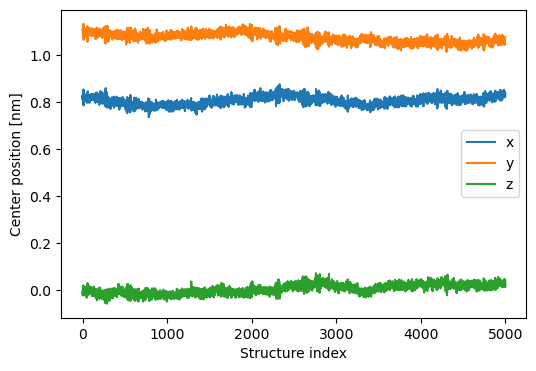

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(center_before[:, 0, 0], label='x')
plt.plot(center_before[:, 0, 1], label='y')
plt.plot(center_before[:, 0, 2], label='z')
plt.xlabel('Structure index')
plt.ylabel('Center position [nm]')
plt.legend()
plt.show()


Now we center the molecular system using {func}`molsysmt.structure.center`:


In [6]:
molsys_centered = msm.structure.center(molsys)
center_after = msm.structure.get_center(molsys_centered)


We verify that the distance of the geometric center from the origin is now zero across all frames:


In [7]:
dist_before = np.linalg.norm(center_before[:, 0, :], axis=1)
dist_after = np.linalg.norm(center_after[:, 0, :], axis=1)


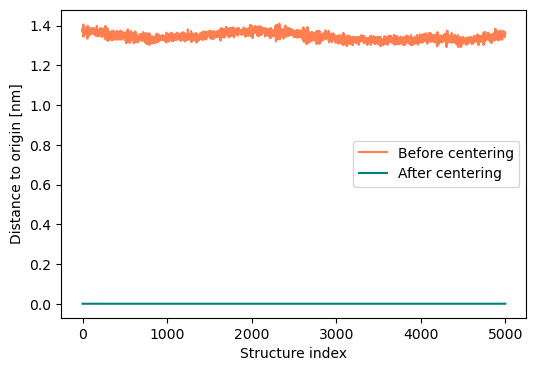

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(dist_before, label='Before centering', color='coral')
plt.plot(dist_after, label='After centering', color='teal')
plt.xlabel('Structure index')
plt.ylabel('Distance to origin [nm]')
plt.legend()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get center <Tutorial_Get_center>`: Compute the geometric center or center of mass with {func}`molsysmt.structure.get_center`.
- {ref}`Get <Tutorial_Get>`: Query atomic coordinates and system attributes with {func}`molsysmt.basic.get`.
- {ref}`Translate <Tutorial_Translate>`: Translate molecular coordinates by a displacement vector with {func}`molsysmt.structure.translate`.
- {ref}`Rotate <Tutorial_Rotate>`: Rotate molecular coordinates with {func}`molsysmt.structure.rotate`.
:::
